#### 2.3.1. Загрузка данных и первичный осмотр

In [ ]:
import pandas as pd

df = pd.read_csv('S02-hw-dataset.csv')

# Вывод первых строк
print("Первые строки датасета:")
print(df.head())
print()

# Информация о данных
print("Информация о данных:")
df.info()
print()

# Описательные статистики
print("Описательные статистики:")
print(df.describe())


Первые строки датасета:
   user_id   age country  purchases  revenue
0        1  25.0      FR          7      749
1        2  24.0      RU          5     1115
2        3  52.0      FR          7      399
3        4  31.0      RU          6      654
4        5   NaN      DE          6     1296

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB

Описательные статистики:
         user_id         age  purchases      revenue
count  41.000000   39.000000  41.000000    41.000000
mean   20.243902   36.512821   4.829268   820.048780
std    11.659289   18.304259   2.710189   613.127269
mi

#### 2.3.2. Пропуски, дубликаты и базовый контроль качества

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('S02-hw-dataset.csv')

print("АНАЛИЗ КАЧЕСТВА ДАННЫХ")
print("=" * 60)

# 1. Доля пропусков
print("\n1. ДОЛЯ ПРОПУСКОВ В КАЖДОМ СТОЛБЦЕ:")
missing_percentage = df.isna().mean() * 100
for col, perc in missing_percentage.items():
    print(f"  {col}: {perc:.1f}% пропусков")

# 2. Дубликаты
print("\n2. ДУБЛИРУЮЩИЕ СТРОКИ:")
duplicates = df.duplicated().sum()
print(f"  Полных дубликатов: {duplicates}")
if duplicates > 0:
    print("\nПримеры дублированных строк:")
    print(df[df.duplicated(keep=False)].head())

print("\n3. ПОДОЗРИТЕЛЬНЫЕ ЗНАЧЕНИЯ:")

# 3.1 Возраст > 100 или < 0
age_issues = df[(df['age'] > 100) | (df['age'] < 0)]
if not age_issues.empty:
    print(f"\n Некорректный возраст (>100 или <0):")
    for idx, row in age_issues.iterrows():
        print(f"     Строка {idx+1}: age={row['age']}")

# 3.2 Нулевой revenue при ненулевых purchases
revenue_issues = df[(df['revenue'] == 0) & (df['purchases'] > 0)]
if not revenue_issues.empty:
    print(f"\n Нулевой доход при ненулевых покупках:")
    for idx, row in revenue_issues.iterrows():
        print(f"     Строка {idx+1}: purchases={row['purchases']}, revenue={row['revenue']}")

# 3.3 Отрицательные purchases
negative_purchases = df[df['purchases'] < 0]
if not negative_purchases.empty:
    print(f"\n Отрицательное количество покупок:")
    for idx, row in negative_purchases.iterrows():
        print(f"     Строка {idx+1}: purchases={row['purchases']}")

# 3.4 Нулевые purchases при ненулевом revenue
purchase_issues = df[(df['purchases'] == 0) & (df['revenue'] > 0)]
if not purchase_issues.empty:
    print(f"\n Нулевые покупки при ненулевом доходе:")
    for idx, row in purchase_issues.iterrows():
        print(f"     Строка {idx+1}: purchases={row['purchases']}, revenue={row['revenue']}")

# 3.5 Отрицательный revenue
negative_revenue = df[df['revenue'] < 0]
if not negative_revenue.empty:
    print(f"\n  Отрицательный доход:")
    for idx, row in negative_revenue.iterrows():
        print(f"     Строка {idx+1}: revenue={row['revenue']}")

АНАЛИЗ КАЧЕСТВА ДАННЫХ

1. ДОЛЯ ПРОПУСКОВ В КАЖДОМ СТОЛБЦЕ:
  user_id: 0.0% пропусков
  age: 4.9% пропусков
  country: 0.0% пропусков
  purchases: 0.0% пропусков
  revenue: 0.0% пропусков

2. ДУБЛИРУЮЩИЕ СТРОКИ:
  Полных дубликатов: 1

Примеры дублированных строк:
    user_id   age country  purchases  revenue
9        10  24.0      RU          7      511
40       10  24.0      RU          7      511

3. ПОДОЗРИТЕЛЬНЫЕ ЗНАЧЕНИЯ:

 Некорректный возраст (>100 или <0):
     Строка 6: age=120.0

 Нулевой доход при ненулевых покупках:
     Строка 11: purchases=4, revenue=0

 Отрицательное количество покупок:
     Строка 6: purchases=-1


В датасете обнаружены следующие проблемы качества данных:
1. Присутствуют пропущенные значения в столбце возраста (4,9% записей), что требует решения о заполнении или удалении этих строк. Также найдена одна полностью дублирующая строка (user_id=10), которая может искажать статистические показатели.

2. Выявлены логические противоречия и некорректные данные: один пользователь имеет нереалистичный возраст 120 лет, другой совершил отрицательное количество покупок (-1), а у третьего зафиксирован нулевой доход при наличии 4 покупок. Эти аномалии требуют дополнительной проверки и корректировки, так как могут существенно влиять на результаты анализа.

#### 2.3.3. Базовый EDA: группировки, агрегаты и частоты

In [12]:
import pandas as pd

df = pd.read_csv('S02-hw-dataset.csv')

print("1. Частоты по странам:")
print(df['country'].value_counts())
print()

print("2. Группировка по странам (средние значения):")
grouped = df.groupby('country').agg({
    'age': 'mean',
    'purchases': ['mean', 'sum'],
    'revenue': ['mean', 'sum']
}).round(2)
print(grouped)
print()

print("3. Возрастные группы:")
df['age_group'] = pd.cut(df['age'], 
                         bins=[0, 20, 30, 40, 50, 60, 120], 
                         labels=['<20', '20-29', '30-39', '40-49', '50-59', '60+'])

# Добавляем observed=True
age_stats = df.groupby('age_group', observed=True).agg({
    'purchases': 'mean',
    'revenue': 'mean',
    'user_id': 'count'
}).round(2)
print(age_stats)

1. Частоты по странам:
country
RU    13
FR    12
US     8
DE     6
CN     2
Name: count, dtype: int64

2. Группировка по странам (средние значения):
           age purchases      revenue       
          mean      mean sum     mean    sum
country                                     
CN       24.00      4.50   9  1054.00   2108
DE       34.60      6.50  39  1445.50   8673
FR       46.25      4.25  51   675.92   8111
RU       30.08      4.77  62   790.08  10271
US       36.71      4.62  37   557.38   4459

3. Возрастные группы:
           purchases  revenue  user_id
age_group                             
<20             6.33  1414.67        3
20-29           4.25   475.00       12
30-39           6.00  1216.27       11
40-49           3.00   668.00        6
50-59           5.00   596.67        6
60+            -1.00   785.00        1


ВЫВОДЫ:

По странам доминируют Россия (RU, 13 пользователей) и Франция (FR, 12 пользователей), составляющие вместе около 61% выборки. При этом пользователи из Германии (DE) демонстрируют наибольшую среднюю выручку (1445.5) и сумму покупок (8673), несмотря на относительно небольшое количество пользователей (6 человек).

Наблюдаются неожиданные эффекты: возрастная группа 30-39 лет показывает самую высокую среднюю выручку (1216.27), хотя не является самой многочисленной. Особенно интересен случай пользователя старше 60 лет, у которого зафиксировано отрицательное количество покупок (-1) при высоком доходе (785), что может указывать на ошибку в данных. Также заметно, что младшая группа (<20 лет) имеет высокую среднюю выручку (1414.67), что может свидетельствовать об эффективных, но редких покупках у молодых пользователей.

### 2.4. Визуализация данных в Matplotlib

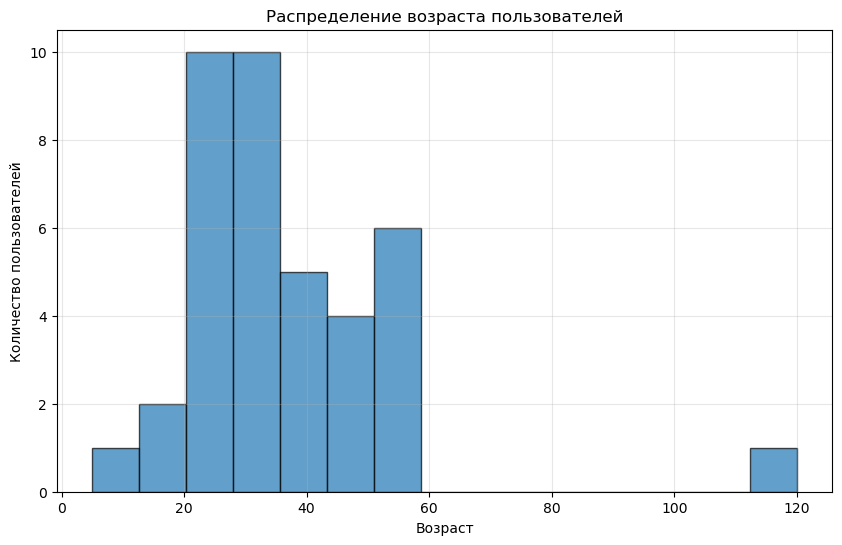

<Figure size 1000x600 with 0 Axes>

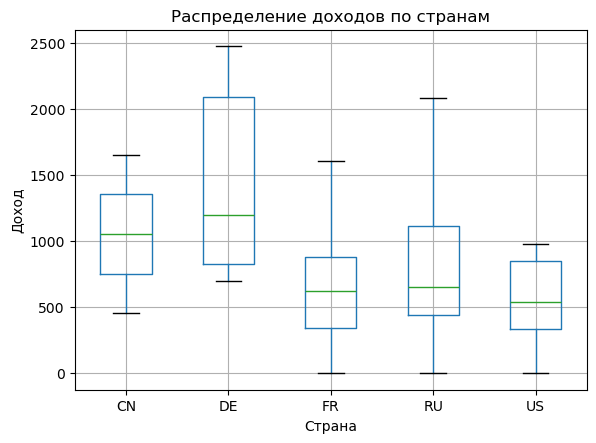

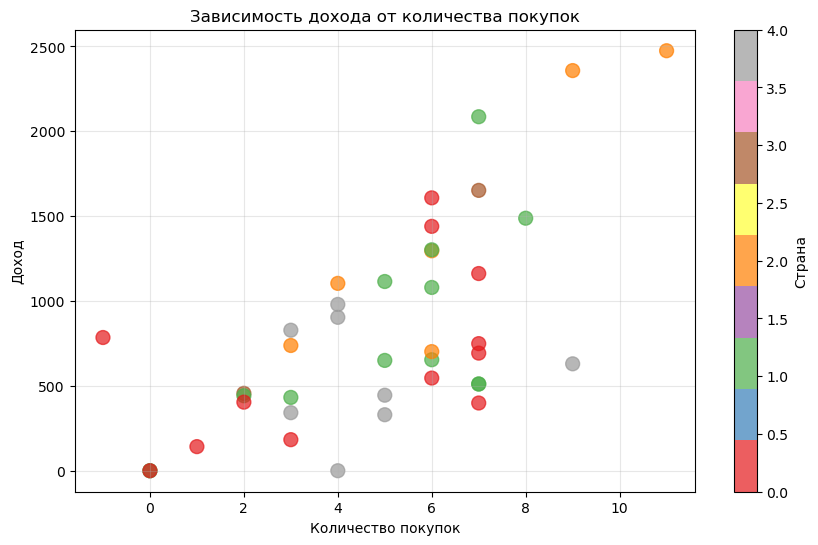

Графики сохранены в папку 'figures/'


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv('S02-hw-dataset.csv')
os.makedirs('figures', exist_ok=True)

# 1. Гистограмма
plt.figure(figsize=(10, 6))
plt.hist(df['age'].dropna(), bins=15, edgecolor='black', alpha=0.7)
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.title('Распределение возраста пользователей')
plt.grid(True, alpha=0.3)
plt.savefig('figures/age_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Боксплот (доход по странам)
plt.figure(figsize=(10, 6))
df.boxplot(column='revenue', by='country', grid=True)
plt.title('Распределение доходов по странам')
plt.suptitle('')  # Убираем автоматический заголовок
plt.xlabel('Страна')
plt.ylabel('Доход')
plt.savefig('figures/revenue_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Scatter plot (покупки vs доход)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['purchases'], df['revenue'], 
                      c=pd.factorize(df['country'])[0], 
                      cmap='Set1', 

                      
                      s=100, 
                      alpha=0.7)
plt.xlabel('Количество покупок')
plt.ylabel('Доход')
plt.title('Зависимость дохода от количества покупок')
plt.colorbar(scatter, label='Страна')
plt.grid(True, alpha=0.3)
plt.savefig('figures/scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Графики сохранены в папку 'figures/'")